In [1]:
import numpy as np
from scipy.optimize import brentq, minimize

In [2]:
a = 2.0
theta_1 = 0.8
theta_2 = 0.5

In [3]:
def U(x):
    return a * x


def lead_times(
    x_1,
    x_2,
    lambda_1,
    lambda_2,
    theta_1,
    theta_2,
    *,
    forced_order=None,
    eps=1e-10,
    tie_rtol=1e-10,
    tie_atol=1e-12,
):
    rho_1 = lambda_1 * x_1
    rho_2 = lambda_2 * x_2
    rho = rho_1 + rho_2

    if min(x_1, x_2, lambda_1, lambda_2, theta_1, theta_2) < 0:
        return None
    if theta_1 <= 0 or theta_2 <= 0 or rho >= 1.0 - eps:
        return None

    ratio_1 = x_1 / theta_1
    ratio_2 = x_2 / theta_2
    if forced_order is None:
        if np.isclose(ratio_1, ratio_2, rtol=tie_rtol, atol=tie_atol):
            order = "FCFS"
        elif ratio_1 < ratio_2:
            order = "1first"
        else:
            order = "2first"
    else:
        order = forced_order

    if order == "FCFS":
        queueing_delay = (lambda_1 * x_1**2 + lambda_2 * x_2**2) / (1.0 - rho)
        w_1 = queueing_delay + x_1
        w_2 = queueing_delay + x_2
    elif order == "1first":
        w_1 = x_1 / (1.0 - rho_1)
        w_2 = x_2 / (1.0 - rho) + lambda_1 * x_1**2 / ((1.0 - rho_1) * (1.0 - rho))
    elif order == "2first":
        w_1 = x_1 / (1.0 - rho) + lambda_2 * x_2**2 / ((1.0 - rho_2) * (1.0 - rho))
        w_2 = x_2 / (1.0 - rho_2)
    else:
        raise ValueError("forced_order must be None, 'FCFS', '1first', or '2first'.")

    return {
        "w_1": float(w_1),
        "w_2": float(w_2),
        "rho_1": float(rho_1),
        "rho_2": float(rho_2),
        "rho": float(rho),
        "order": order,
        "ratio_1": float(ratio_1),
        "ratio_2": float(ratio_2),
    }


def evaluate_policy(
    x_1,
    x_2,
    lambda_1,
    lambda_2,
    theta_1,
    theta_2,
    *,
    forced_order=None,
    eps=1e-10,
):
    stats = lead_times(
        x_1,
        x_2,
        lambda_1,
        lambda_2,
        theta_1,
        theta_2,
        forced_order=forced_order,
        eps=eps,
    )
    if stats is None:
        return None

    welfare = (
        lambda_1 * (U(x_1) - theta_1 * stats["w_1"])
        + lambda_2 * (U(x_2) - theta_2 * stats["w_2"])
    )
    lambda_total = lambda_1 + lambda_2
    normalized_welfare = welfare / lambda_total if lambda_total > 0 else np.nan

    return {
        "x_1": float(x_1),
        "x_2": float(x_2),
        "welfare": float(welfare),
        "normalized_welfare": float(normalized_welfare),
        **stats,
    }


def compute_welfare(x_1, x_2, lambda_1, lambda_2, theta_1, theta_2, *, normalized=False):
    out = evaluate_policy(x_1, x_2, lambda_1, lambda_2, theta_1, theta_2)
    if out is None:
        return None
    key = "normalized_welfare" if normalized else "welfare"
    return out[key], out

In [4]:
def _x_from_rho(rho_1, rho_2, lambda_1, lambda_2):
    x_1 = rho_1 / lambda_1 if lambda_1 > 0 else 0.0
    x_2 = rho_2 / lambda_2 if lambda_2 > 0 else 0.0
    return float(x_1), float(x_2)


def _candidate_from_rho(rho, lambda_1, lambda_2, theta_1, theta_2, *, forced_order=None, eps=1e-10):
    rho_1, rho_2 = map(float, rho)
    if rho_1 < 0 or rho_2 < 0 or rho_1 + rho_2 >= 1.0 - eps:
        return None
    x_1, x_2 = _x_from_rho(rho_1, rho_2, lambda_1, lambda_2)
    return evaluate_policy(
        x_1,
        x_2,
        lambda_1,
        lambda_2,
        theta_1,
        theta_2,
        forced_order=forced_order,
        eps=eps,
    )


def _starting_rhos(lambda_1, lambda_2, theta_1, theta_2, *, eps=1e-10, n=7):
    starts = [(0.0, 0.0)]
    if lambda_1 > 0:
        starts.append((min(0.5, 1.0 - 2 * eps), 0.0))
        starts.append((max(0.0, 1.0 - np.sqrt(theta_1 / a)), 0.0))
    if lambda_2 > 0:
        starts.append((0.0, min(0.5, 1.0 - 2 * eps)))
        starts.append((0.0, max(0.0, 1.0 - np.sqrt(theta_2 / a))))

    grid = np.linspace(0.02, 0.80, n)
    for rho_1 in grid:
        for rho_2 in grid:
            if rho_1 + rho_2 < 0.95:
                starts.append((float(rho_1), float(rho_2)))

    heavy_fractions = np.linspace(0.05, 0.95, n)
    for total_load in [0.95, 0.99, 0.999, 0.9999]:
        for frac in heavy_fractions:
            starts.append((float(total_load * frac), float(total_load * (1.0 - frac))))
    return starts


def optimize_regime(lambda_1, lambda_2, theta_1, theta_2, order, *, eps=1e-10):
    if order not in {"1first", "2first"}:
        raise ValueError("order must be '1first' or '2first'.")

    bounds = [
        (0.0, 1.0 - eps) if lambda_1 > 0 else (0.0, 0.0),
        (0.0, 1.0 - eps) if lambda_2 > 0 else (0.0, 0.0),
    ]

    def priority_constraint(rho):
        rho_1, rho_2 = rho
        if lambda_1 == 0 or lambda_2 == 0:
            return 0.0
        ratio_1 = rho_1 / (lambda_1 * theta_1)
        ratio_2 = rho_2 / (lambda_2 * theta_2)
        return ratio_2 - ratio_1 if order == "1first" else ratio_1 - ratio_2

    constraints = [
        {"type": "ineq", "fun": lambda rho: 1.0 - eps - rho[0] - rho[1]},
        {"type": "ineq", "fun": priority_constraint},
    ]

    def objective(rho):
        out = _candidate_from_rho(rho, lambda_1, lambda_2, theta_1, theta_2, forced_order=order, eps=eps)
        if out is None:
            return 1e12
        return -out["welfare"] / max(abs(a), 1.0)

    best = None
    for start in _starting_rhos(lambda_1, lambda_2, theta_1, theta_2, eps=eps):
        if start[0] + start[1] >= 1.0 - eps:
            continue
        if priority_constraint(start) < -1e-9:
            continue
        res = minimize(
            objective,
            x0=np.array(start, dtype=float),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-12, "maxiter": 1000, "disp": False},
        )
        out = _candidate_from_rho(res.x, lambda_1, lambda_2, theta_1, theta_2, forced_order=order, eps=eps)
        if out is None:
            continue
        out = {**out, "regime": order, "success": bool(res.success), "message": res.message}
        if best is None or out["welfare"] > best["welfare"]:
            best = out
    return best


def optimize_proposition1(lambda_1, lambda_2, theta_1, theta_2, *, eps=1e-10):
    candidates = []
    for order in ["1first", "2first"]:
        out = optimize_regime(lambda_1, lambda_2, theta_1, theta_2, order, eps=eps)
        if out is not None:
            candidates.append(out)

    best = max(candidates, key=lambda row: row["welfare"])
    final = evaluate_policy(best["x_1"], best["x_2"], lambda_1, lambda_2, theta_1, theta_2, eps=eps)
    return {**final, "all_candidates": candidates}

In [5]:
def lambdas_from_ratio(ratio, lambda_total=1.0):
    if ratio <= 0:
        raise ValueError("ratio = lambda_2 / lambda_1 must be positive.")
    lambda_1 = lambda_total / (1.0 + ratio)
    lambda_2 = lambda_total * ratio / (1.0 + ratio)
    return float(lambda_1), float(lambda_2)


def priority_gap_for_ratio(ratio, theta_1, theta_2, *, lambda_total=1.0, eps=1e-10):
    lambda_1, lambda_2 = lambdas_from_ratio(ratio, lambda_total=lambda_total)
    one_first = optimize_regime(lambda_1, lambda_2, theta_1, theta_2, "1first", eps=eps)
    two_first = optimize_regime(lambda_1, lambda_2, theta_1, theta_2, "2first", eps=eps)
    if one_first is None or two_first is None:
        raise RuntimeError("Could not solve both priority regimes at this ratio.")
    gap = (one_first["welfare"] - two_first["welfare"]) / max(abs(a), 1.0)
    return gap, one_first, two_first


def find_priority_threshold_c(
    theta_1,
    theta_2,
    *,
    a_value=None,
    r_min=1e-4,
    r_max=1e4,
    n_scan=81,
    lambda_total=1.0,
    eps=1e-10,
):
    global a
    old_a = a
    if a_value is not None:
        a = float(a_value)

    try:
        if not (a > theta_1 > theta_2 > 0):
            raise ValueError("Proposition 1 assumes a > theta_1 > theta_2 > 0.")
        if theta_1**2 >= a * theta_2:
            return {
                "c": None,
                "case": "exclusion",
                "message": "theta_1^2 >= a theta_2, so Proposition 1 sets x_1*=0 and no finite priority threshold is needed.",
            }

        def gap_only(ratio):
            gap, _, _ = priority_gap_for_ratio(
                ratio,
                theta_1,
                theta_2,
                lambda_total=lambda_total,
                eps=eps,
            )
            return gap

        ratios = np.geomspace(r_min, r_max, n_scan)
        gaps = np.array([gap_only(r) for r in ratios])
        bracket = None
        for left, right, g_left, g_right in zip(ratios[:-1], ratios[1:], gaps[:-1], gaps[1:]):
            if np.isclose(g_left, 0.0, atol=1e-8):
                bracket = (left, left)
                break
            if g_left * g_right < 0:
                bracket = (left, right)
                break

        if bracket is None:
            raise RuntimeError("Could not bracket c. Try increasing r_max/r_min or n_scan.")

        left, right = bracket
        c = left if left == right else brentq(gap_only, left, right, xtol=1e-10, rtol=1e-10)
        gap, one_first, two_first = priority_gap_for_ratio(
            c,
            theta_1,
            theta_2,
            lambda_total=lambda_total,
            eps=eps,
        )

        return {
            "c": float(c),
            "case": "positive_service",
            "gap_at_c": float(gap),
            "one_first_at_c": one_first,
            "two_first_at_c": two_first,
            "scan_ratios": ratios,
            "scan_gaps": gaps,
        }
    finally:
        if a_value is not None:
            a = old_a


#find_priority_threshold_c(theta_1, theta_2)

In [6]:
import matplotlib.pyplot as plt


def a_from_exclusion_index(z, theta_1, theta_2):
    """Return a such that z = theta_1^2 / (a theta_2)."""
    if z <= 0:
        raise ValueError("z must be positive.")
    return theta_1**2 / (z * theta_2)


def default_exclusion_index_grid(n_left=18, n_near_boundary=14, z_min=0.05, z_mid=0.85, z_max=0.985):
    low_z = np.array([0.001, 0.01, 0.03])
    left = np.linspace(z_min, z_mid, n_left, endpoint=False)
    near = 1.0 - np.geomspace(1.0 - z_mid, 1.0 - z_max, n_near_boundary)
    return np.unique(np.concatenate([low_z, left, near]))


def approximate_c_at_zero(theta_1, theta_2):
    """Large-a approximation for c at z = theta_1^2 / (a theta_2) = 0."""
    q = theta_1 / theta_2
    if q <= 1.0:
        raise ValueError("Need theta_1 > theta_2 for Proposition 1.")

    def equation(s):
        return np.sqrt(1.0 + s**2) * (s - q) - s * (q - 1.0)

    upper = max(10.0, 4.0 * q)
    while equation(upper) <= 0.0:
        upper *= 2.0
    s = brentq(equation, q + 1e-12, upper, xtol=1e-12, rtol=1e-12)
    return float(s**2)


def compute_priority_threshold_curve(
    theta_1,
    theta_2,
    *,
    z_grid=None,
    lambda_total=1.0,
    r_min=1e-3,
    r_max=1e6,
    n_scan=17,
    verbose=True,
):
    if z_grid is None:
        z_grid = default_exclusion_index_grid()

    rows = []
    for z in z_grid:
        a_value = a_from_exclusion_index(z, theta_1, theta_2)
        if z >= 1.0:
            rows.append({"z": float(z), "a": float(a_value), "c": np.nan, "case": "exclusion"})
            continue

        out = find_priority_threshold_c(
            theta_1,
            theta_2,
            a_value=a_value,
            lambda_total=lambda_total,
            r_min=r_min,
            r_max=r_max,
            n_scan=n_scan,
        )
        rows.append({"z": float(z), "a": float(a_value), "c": out["c"], "case": out["case"]})
        if verbose:
            print(f"z={z:.4f}, a={a_value:.4f}, c={out['c']:.6g}")
    return rows


def threshold_curve_arrays(curve, theta_1, theta_2, *, include_zero=True, c_zero=None):
    z = np.array([row["z"] for row in curve], dtype=float)
    c = np.array([row["c"] for row in curve], dtype=float)
    finite = np.isfinite(c)
    z_line = z[finite]
    c_line = c[finite]
    if include_zero:
        c0 = approximate_c_at_zero(theta_1, theta_2) if c_zero is None else float(c_zero)
        z_line = np.concatenate(([0.0], z_line))
        c_line = np.concatenate(([c0], c_line))
    order = np.argsort(z_line)
    z_line = z_line[order]
    c_line = c_line[order]
    return z_line, c_line


def plot_priority_threshold_curve_from_data(
    curve,
    theta_1,
    theta_2,
    *,
    include_zero=True,
    c_zero=None,
    y_min=0.5,
    y_max=1e3,
    ax=None,
    figsize=(7.2, 4.8),
    colors=None,
    alphas=None,
    curve_kwargs=None,
    show_grid=True,
    show_legend=True,
):
    z_line, c_line = threshold_curve_arrays(
        curve,
        theta_1,
        theta_2,
        include_zero=include_zero,
        c_zero=c_zero,
    )
    y_min = float(y_min)
    y_max = float(y_max)
    if y_min <= 0 or y_max <= y_min:
        raise ValueError("Need 0 < y_min < y_max for the log-scale plot.")
    c_visible = np.clip(c_line, y_min, y_max)

    if colors is None:
        colors = {
            "type1": "#6BAED6",
            "type2": "#F4A582",
            "excluded": "#A1D99B",
            "curve": "black",
        }
    if alphas is None:
        alphas = {"type1": 0.22, "type2": 0.28, "excluded": 0.35}
    if curve_kwargs is None:
        curve_kwargs = {}
    curve_style = {"color": colors["curve"], "linewidth": 2.0, "label": r"$c$"}
    curve_style.update(curve_kwargs)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.axvspan(1.0, 1.10, color=colors["excluded"], alpha=alphas["excluded"], label="Type 1 excluded")
    ax.axvspan(0.0, 1.0, color=colors["type1"], alpha=alphas["type1"], label="Type 1 prioritized")
    ax.fill_between(z_line, c_visible, y_max, color=colors["type2"], alpha=alphas["type2"], label="Type 2 prioritized")
    ax.plot(z_line, c_line, **curve_style)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2)
    ax.set_yscale("log")
    ax.set_xlim(0.0, 1.10)
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_label_coords(-0.10, 0.5)
    ax.set_xlabel(r"$\frac{\theta_1^2}{a\theta_2}$", fontsize=24)
    ax.set_ylabel(r"$\frac{\lambda_2}{\lambda_1}$", fontsize=24, rotation=0)
    #ax.set_title(r"Priority-switch threshold $c$")
    if show_grid:
        ax.grid(True, which="both", alpha=0.3)
    if show_legend:
        ax.legend(fontsize=16, loc="upper left")
    fig.tight_layout()
    fig.savefig("prop1_1.pdf")
    return fig, ax


def plot_priority_threshold_curve(
    theta_1,
    theta_2,
    *,
    lambda_total=1.0,
    z_grid=None,
    r_min=1e-3,
    r_max=1e6,
    n_scan=17,
    verbose=True,
    **plot_kwargs,
):
    curve = compute_priority_threshold_curve(
        theta_1,
        theta_2,
        lambda_total=lambda_total,
        z_grid=z_grid,
        r_min=r_min,
        r_max=r_max,
        n_scan=n_scan,
        verbose=verbose,
    )
    fig, ax = plot_priority_threshold_curve_from_data(curve, theta_1, theta_2, **plot_kwargs)
    return fig, ax, curve

In [7]:
# Step 1: compute once.
curve = compute_priority_threshold_curve(theta_1=0.7, theta_2=0.6, lambda_total=1.0)

z=0.0010, a=816.6667, c=1.71471
z=0.0100, a=81.6667, c=1.78234
z=0.0300, a=27.2222, c=1.86803
z=0.0500, a=16.3333, c=1.9373
z=0.0944, a=8.6471, c=2.07732
z=0.1389, a=5.8800, c=2.21633
z=0.1833, a=4.4545, c=2.3633
z=0.2278, a=3.5854, c=2.52386
z=0.2722, a=3.0000, c=2.70321
z=0.3167, a=2.5789, c=2.90721
z=0.3611, a=2.2615, c=3.14309
z=0.4056, a=2.0137, c=3.42033
z=0.4500, a=1.8148, c=3.75179
z=0.4944, a=1.6517, c=4.1556
z=0.5389, a=1.5155, c=4.65813
z=0.5833, a=1.4000, c=5.29929
z=0.6278, a=1.3009, c=6.1422
z=0.6722, a=1.2149, c=7.29215
z=0.7167, a=1.1395, c=8.93704
z=0.7611, a=1.0730, c=11.4424
z=0.8056, a=1.0138, c=15.6077
z=0.8500, a=0.9608, c=23.5011
z=0.8743, a=0.9340, c=31.4052
z=0.8947, a=0.9127, c=42.2971
z=0.9118, a=0.8956, c=57.3752
z=0.9261, a=0.8818, c=78.333
z=0.9381, a=0.8705, c=107.568
z=0.9482, a=0.8613, c=148.475
z=0.9566, a=0.8537, c=205.873
z=0.9636, a=0.8475, c=286.595
z=0.9695, a=0.8423, c=400.35
z=0.9745, a=0.8381, c=560.932
z=0.9786, a=0.8345, c=787.952
z=0.9821, a

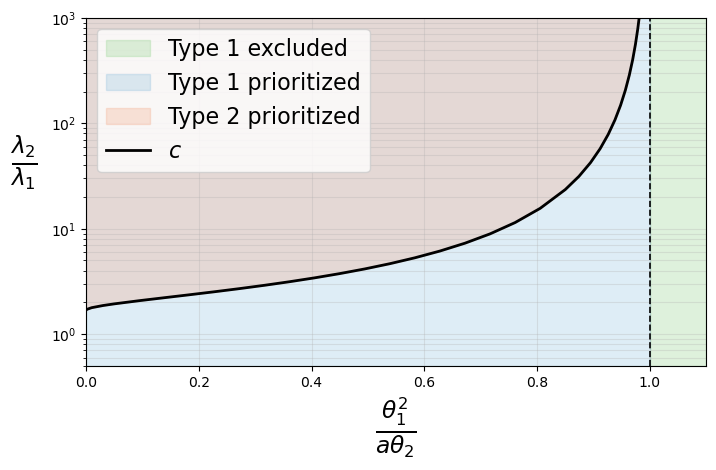

In [8]:
# Step 2: re-plot from the saved curve as many times as you want.
fig, ax = plot_priority_threshold_curve_from_data(curve, theta_1=0.7, theta_2=0.6, y_max=1000.0)

In [9]:
from matplotlib.ticker import NullLocator


def compute_priority_regime_welfare_curves(
    *,
    a_value=2.0,
    theta_1=0.7,
    theta_2=0.6,
    lambda_total=1.0,
    ratios=None,
    r_min=0.01,
    r_max=100.0,
    n_points=41,
    verbose=True,
):
    global a
    old_a = a
    a = float(a_value)
    try:
        if ratios is None:
            ratios = np.geomspace(r_min, r_max, n_points)

        rows = []
        for ratio in ratios:
            lambda_1, lambda_2 = lambdas_from_ratio(ratio, lambda_total=lambda_total)
            one_first = optimize_regime(lambda_1, lambda_2, theta_1, theta_2, "1first")
            two_first = optimize_regime(lambda_1, lambda_2, theta_1, theta_2, "2first")
            rows.append(
                {
                    "ratio": float(ratio),
                    "lambda_1": lambda_1,
                    "lambda_2": lambda_2,
                    "welfare_1first": one_first["welfare"],
                    "welfare_2first": two_first["welfare"],
                    "x1_1first": one_first["x_1"],
                    "x2_1first": one_first["x_2"],
                    "x1_2first": two_first["x_1"],
                    "x2_2first": two_first["x_2"],
                }
            )
            if verbose:
                print(
                    f"ratio={ratio:.4g}, "
                    f"W_1first={one_first['welfare']:.6g}, "
                    f"W_2first={two_first['welfare']:.6g}"
                )
        return rows
    finally:
        a = old_a


def reference_welfare_levels(a_value, theta_1, theta_2):
    return {
        "joint": a_value + theta_1 + theta_2 - 3.0 * np.cbrt(a_value * theta_1 * theta_2),
        "type2_only": a_value + theta_2 - 2.0 * np.sqrt(a_value * theta_2),
        "type1_only": a_value + theta_1 - 2.0 * np.sqrt(a_value * theta_1),
    }


def plot_priority_regime_welfare_curves(
    rows,
    *,
    a_value=2.0,
    theta_1=0.7,
    theta_2=0.6,
    ax=None,
    figsize=(7.2, 4.8),
    xscale="log",
    show_reference_lines=True,
    show_grid=True,
    show_legend=True,
):
    ratio = np.array([row["ratio"] for row in rows], dtype=float)
    welfare_1first = np.array([row["welfare_1first"] for row in rows], dtype=float)
    welfare_2first = np.array([row["welfare_2first"] for row in rows], dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.plot(ratio, welfare_1first, color="#2B6CB0", linewidth=2.4, label="Type 1 prioritized")
    ax.plot(ratio, welfare_2first, color="#C05621", linewidth=2.4, label="Type 2 prioritized")
    ref_values = []
    if show_reference_lines:
        refs = reference_welfare_levels(a_value, theta_1, theta_2)
        ref_items = sorted(refs.items(), key=lambda item: item[1])
        ref_values = [value for _, value in ref_items]
        for value in ref_values:
            ax.axhline(value, color="0.25", linestyle="--", linewidth=1.2, alpha=0.75)
        ax.set_yticks(ref_values)
        ax.set_yticklabels([r"$\mathcal{W}_2$", r"$\mathcal{W}_1$", r"$\mathcal{W}_0$"], fontsize=10)
        ax.yaxis.set_minor_locator(NullLocator())
        all_values = np.concatenate([welfare_1first, welfare_2first, np.array(ref_values, dtype=float)])
        margin = 0.08 * (np.nanmax(all_values) - np.nanmin(all_values))
        ax.set_ylim(np.nanmin(all_values) - margin, np.nanmax(all_values) + margin)
    #ax.set_ylim([0,0.5])
    ax.set_xscale(xscale)
    ax.set_xlabel(r"$\frac{\lambda_2}{\lambda_1}$", fontsize=24)
    ax.set_ylabel(r"$\mathcal{W}$", rotation=0, fontsize=24, labelpad=34)
    ax.yaxis.set_label_coords(-0.10, 0.5)
    ax.tick_params(axis="y", which="major", pad=8)
    if show_grid:
        ax.grid(True, which="both", alpha=0.3)
    if show_legend:
        ax.legend(fontsize=16, loc="lower center", bbox_to_anchor=(0.75, 0.10))
    fig.tight_layout()
    fig.savefig("prop1_2.pdf")
    return fig, ax


In [10]:
priority_welfare_curve = compute_priority_regime_welfare_curves(
    a_value=2.0,
    theta_1=0.7,
    theta_2=0.6,
    lambda_total=1.0,
    verbose=True,
)

ratio=0.01, W_1first=0.468265, W_2first=0.334282
ratio=0.01259, W_1first=0.467984, W_2first=0.334466
ratio=0.01585, W_1first=0.467633, W_2first=0.334696
ratio=0.01995, W_1first=0.467198, W_2first=0.334985
ratio=0.02512, W_1first=0.466661, W_2first=0.335346
ratio=0.03162, W_1first=0.466, W_2first=0.335798
ratio=0.03981, W_1first=0.465192, W_2first=0.336361
ratio=0.05012, W_1first=0.46421, W_2first=0.337063
ratio=0.0631, W_1first=0.463027, W_2first=0.337935
ratio=0.07943, W_1first=0.461614, W_2first=0.339014
ratio=0.1, W_1first=0.459946, W_2first=0.340343
ratio=0.1259, W_1first=0.458003, W_2first=0.341974
ratio=0.1585, W_1first=0.455773, W_2first=0.343961
ratio=0.1995, W_1first=0.453256, W_2first=0.346365
ratio=0.2512, W_1first=0.450468, W_2first=0.349247
ratio=0.3162, W_1first=0.447444, W_2first=0.352667
ratio=0.3981, W_1first=0.444234, W_2first=0.356675
ratio=0.5012, W_1first=0.440905, W_2first=0.361307
ratio=0.631, W_1first=0.437535, W_2first=0.366573
ratio=0.7943, W_1first=0.434205, 

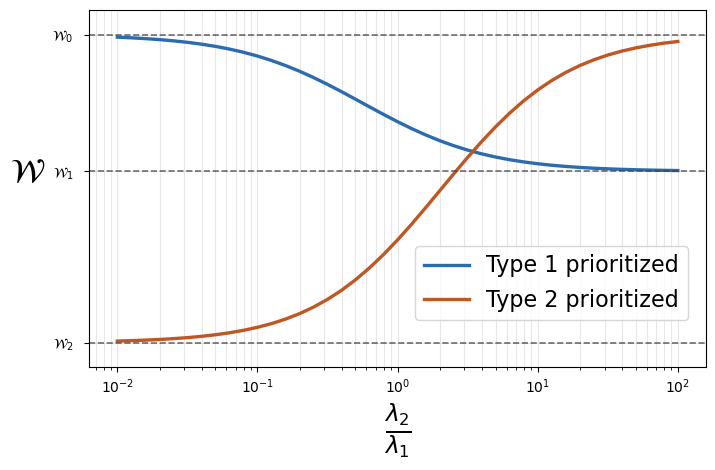

In [11]:
fig_priority_welfare, ax_priority_welfare = plot_priority_regime_welfare_curves(priority_welfare_curve)